# Integration of SN_DA013 D40+D100+D80 clusters

## Human, Chimp, Orangutan and Macaque

V4 - new individual demultiplexing as of December 5, 2023

## Import data and functions

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt
import scrublet 


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()


The `sinfo` package has changed name and is now called `session_info` to become more discoverable and self-explanatory. The `sinfo` PyPI package will be kept around to avoid breaking old installs and you can downgrade to 0.3.2 if you want to use it without seeing this message. For the latest features and bug fixes, please install `session_info` instead. The usage and defaults also changed slightly, so please review the latest README at https://gitlab.com/joelostblom/session_info.
-----
anndata     0.8.0
scanpy      1.8.2
sinfo       0.3.4
-----
PIL                         9.0.1
annoy                       NA
appnope                     0.1.2
asttokens                   NA
backcall                    0.2.0
bbknn                       NA
beta_ufunc                  NA
binom_ufunc                 NA
cffi                        1.15.0
colorama                    0.4.4
cycler                      0.10.0
cython_runtime              NA
dateutil                    2.8.2
debugpy                

In [3]:
pwd

'/Users/saranolbrant/Dropbox/Postdoc Pollen lab/Comparative DA study/10x Multiome sequencing/10x GEX data/20220406_SN_DA013_D16v2_D40_D100_D80_GEX'

In [4]:
#set a path to your working directory
directory='Set/your/path'

adata = sc.read_h5ad(directory+'/Written_files/GEX_D40-D100-D80.h5ad')



In [5]:
adata.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,pool_type,species,time_point,experiment,day_10x,lane,n_genes,percent_mito,percent_ribo,n_counts,leiden,supervised_name
AAACAGCCACAACAGG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H20961,S,436.225447,Intraspecies,human,D40,first_experiment,Run_20211206,Lane2,2837,0.002298,0.007660,6512.0,9,MB/HB FP cells
AAACAGCCATCTAGCA-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.4,C.4,H21792,S,636.853818,Intraspecies,human,D40,first_experiment,Run_20211206,Lane2,3364,0.002342,0.005671,8093.0,3,"DA/STN neurons, immature"
AAACATGCAACAGCCT-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H29089,S,354.373208,Intraspecies,human,D40,first_experiment,Run_20211206,Lane2,3020,0.004305,0.015731,6012.0,25,MB/HB glutamatergic neurons
AAACATGCATCAATCG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H20961,S,215.154958,Intraspecies,human,D40,first_experiment,Run_20211206,Lane2,2979,0.002080,0.007724,6718.0,7,Ventral FB/MB progenitors
AAACATGCATTATGCG-1-D40_CH_2_Human,D40_CH_2_Human,singlet,C.8,C.8,H28126,S,392.516627,Intraspecies,human,D40,first_experiment,Run_20211206,Lane2,2556,0.000185,0.006648,5414.0,21,"Ventral FB/MB progenitors, cycling"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGAGTCAATGAAGC-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C3651,S,17.289815,Intraspecies,chimp,D40,outgroup_experiment,Run_20230126,Lane15,3264,0.005036,0.011842,7310.0,12,Lateral MB progenitors
TTTGGCTGTATTGTCC-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C40300,S,16.480662,Intraspecies,chimp,D40,outgroup_experiment,Run_20230126,Lane15,3324,0.010348,0.010979,7842.0,19,"MB/HB neurons, LHX1+"
TTTGGTGCATGGCCTG-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C40210,S,0.471806,Intraspecies,chimp,D40,outgroup_experiment,Run_20230126,Lane15,3053,0.011312,0.017182,6903.0,12,Lateral MB progenitors
TTTGTCCCAGGCCTTG-1-D40_outgroup-exp_1_Chimp,D40_outgroup-exp_1_Chimp,NaN,NaN,C.8,C8861,S,3.700542,Intraspecies,chimp,D40,outgroup_experiment,Run_20230126,Lane15,2484,0.008603,0.010840,5762.0,17,"MB/HB glutamatergic neurons, immature"


In [6]:
adata

AnnData object with n_obs × n_vars = 105777 × 51861
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'pool_type', 'species', 'time_point', 'experiment', 'day_10x', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden', 'supervised_name'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gene_ids-D100_M_0-6_Human', 'feat

In [7]:
individual_pooltype = pd.Categorical(adata.obs['individual'].astype(str) + ('_') + adata.obs['pool_type'].astype(str))

adata.obs['individual_pooltype'] = individual_pooltype

In [8]:
adata.obs['individual_pooltype'].value_counts()

O11045-4593_Intraspecies    11215
ZG15-M11-10_Intraspecies     9504
ES_Lyon_Intraspecies         9259
ZH26-HS16_Intraspecies       8565
C8861_Interspecies           6969
C4933_Interspecies           5453
C3651_Interspecies           4381
C3624_Interspecies           4260
H20961_Interspecies          4132
H20961_Intraspecies          4127
C4933_Intraspecies           3488
H29089_Intraspecies          2918
C8861_Intraspecies           2914
C40210_Interspecies          2682
H29089_Interspecies          2402
C40670_Interspecies          2350
H28834_Intraspecies          2045
C40300_Interspecies          1525
H9_Intraspecies              1514
C3651_Intraspecies           1514
H21792_Interspecies          1326
H21792_Intraspecies          1241
H9_Interspecies              1221
C40670_Intraspecies          1175
H28834_Interspecies          1039
H23555_Interspecies          1001
H21194_Interspecies           965
H21194_Intraspecies           953
C40210_Intraspecies           853
H23555_Intrasp

In [11]:
#Change the values of this dictionary to assign the name you want to each of the leiden clusters
labeldict={'0':'MB/HB neurons, LHX1+',
           '1':'STN neurons',
           '2':'DA neurons',
           '3':'DA/STN neurons, immature',
           '4':'MB/HB FP cells',
           '5':'Ventral FB/MB progenitors',
           '6':'DA neurons',
           '7':'Ventral FB/MB progenitors',
           '8':'STN neurons',
           '9':'MB/HB FP cells',
           '10':'Low quality/technical',
           '11':'MB/HB glutamatergic neurons',
           '12':'Lateral MB progenitors',
           '13':'DA neurons',
           '14':'Lateral MB progenitors, cycling',
           '15':'Glial progenitors/astrocytes',
           '16':'Lateral MB progenitors',
           '17':'MB/HB glutamatergic neurons, immature',
           '18':'DA/STN neurons, immature',
           '19':'MB/HB neurons, LHX1+',
           '20':'Hypothalamic neurons',
           '21':'Ventral FB/MB progenitors, cycling',
           '22':'Low quality/technical',
           '23':'MB glutamatergic neurons',
           '24':'Low quality/technical',
           '25':'MB/HB glutamatergic neurons',
           '26':'MB GABAergic neurons',
           '27':'FB progenitors',
           '28':'Oculomotor neurons',
           '29':'Progenitors, cycling',

           }



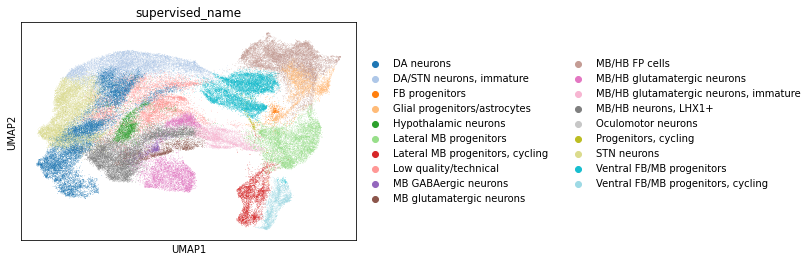

In [12]:
#Assign a supervised name for each leiden cluster
#Will error out if you missed a cluster
adata.obs['supervised_name']=[labeldict[x] for x in adata.obs['leiden']]
sc.pl.umap(adata,color=['supervised_name'], palette="tab20")

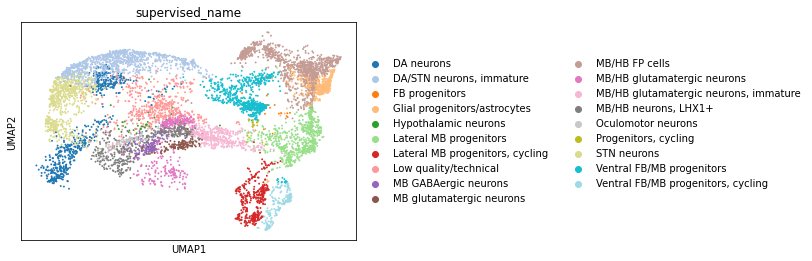

In [15]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H20961_Interspecies|H20961_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H20961')

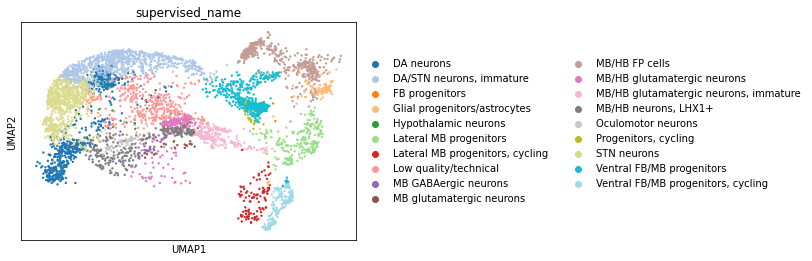

In [16]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H29089_Interspecies|H29089_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H29089')

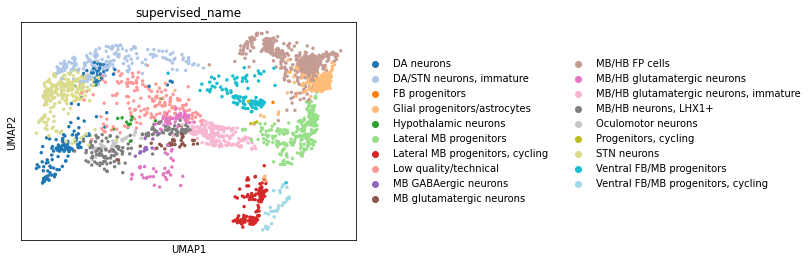

In [17]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H21792_Interspecies|H21792_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H21792')

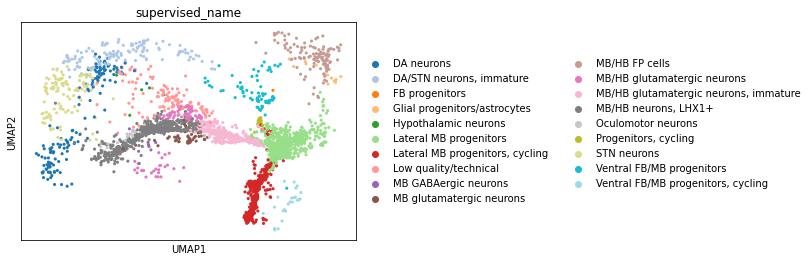

In [18]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H28834_Interspecies|H28834_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H28834')

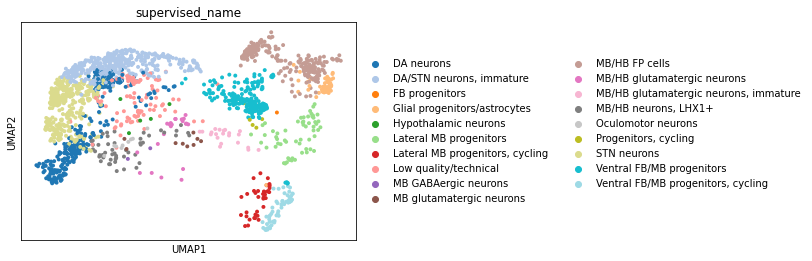

In [20]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H21194_Interspecies|H21194_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H21194')

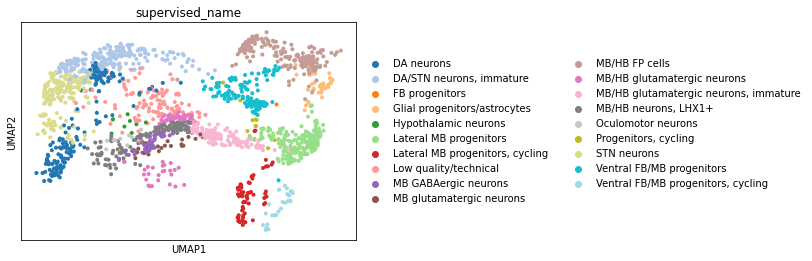

In [21]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H23555_Interspecies|H23555_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H23555')

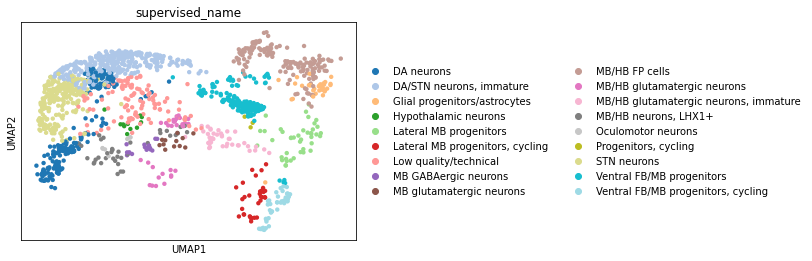

In [23]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H28126_Interspecies|H28126_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H28126')

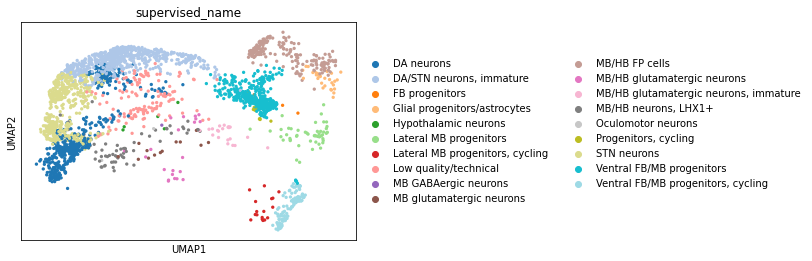

In [24]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('H9_Interspecies|H9_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_H9')

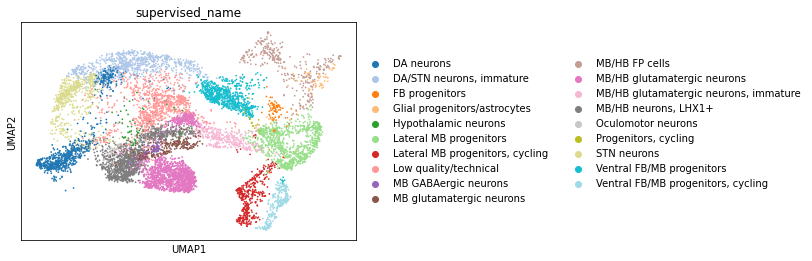

In [25]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C8861_Interspecies|C8861_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C8861')

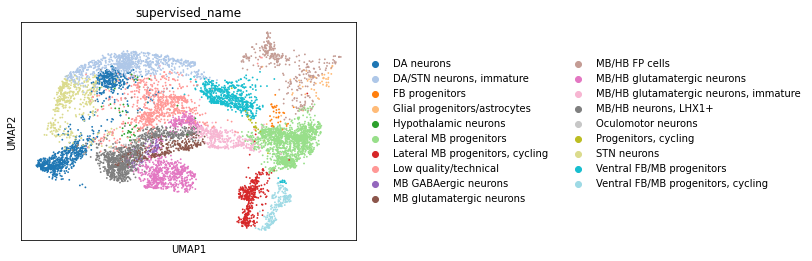

In [26]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C4933_Interspecies|C4933_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C4933')

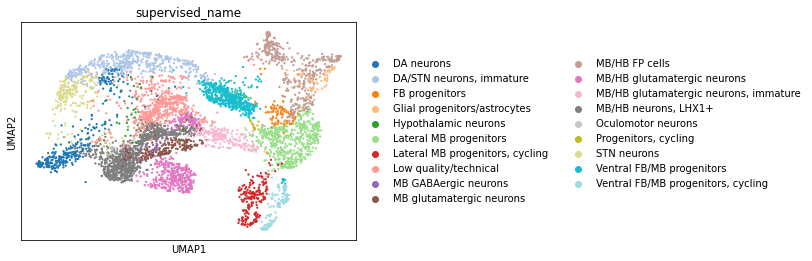

In [27]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C3651_Interspecies|C3651_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C3651')

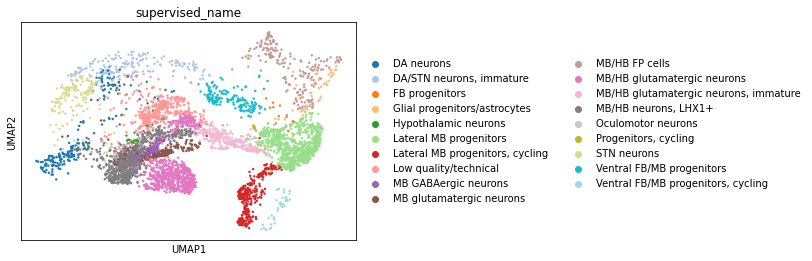

In [28]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C3624_Interspecies|C3624_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C3624')

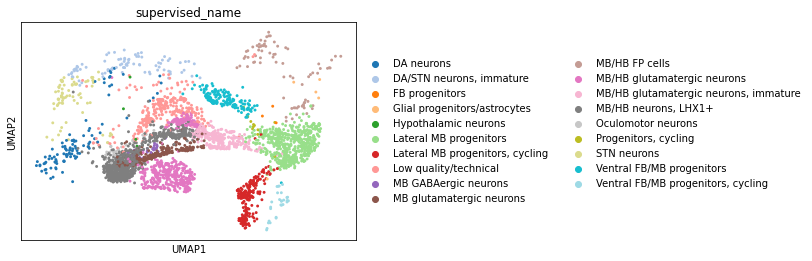

In [29]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C40210_Interspecies|C40210_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C40210')

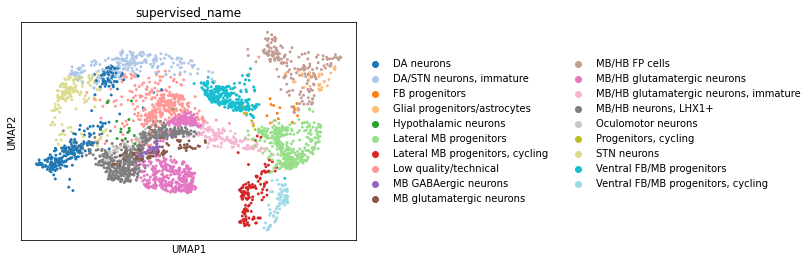

In [30]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C40670_Interspecies|C40670_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C40670')

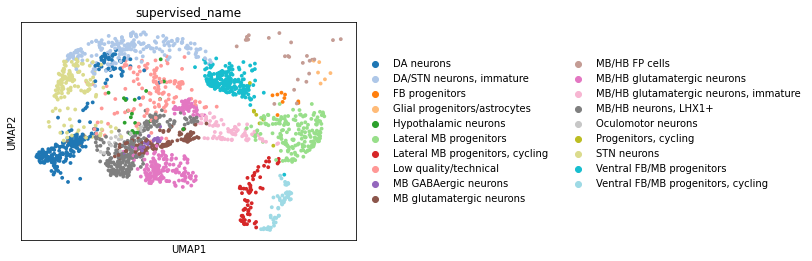

In [31]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('C40300_Interspecies|C40300_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_C40300')

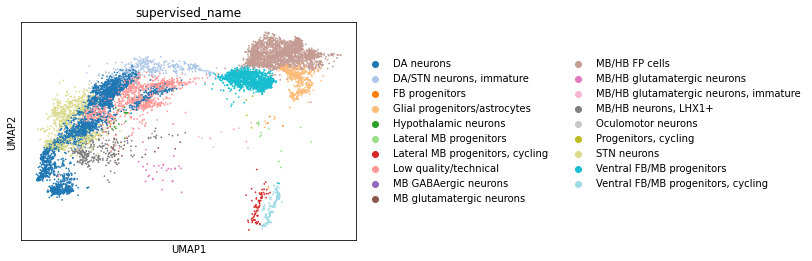

In [32]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('ES_Lyon_Interspecies|ES_Lyon_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_ES-Lyon')

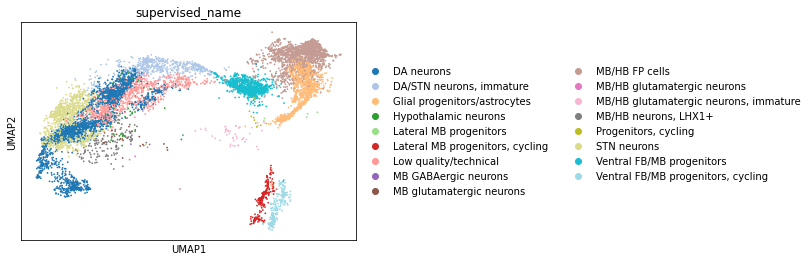

In [33]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('ZG15-M11-10_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_ZG15')

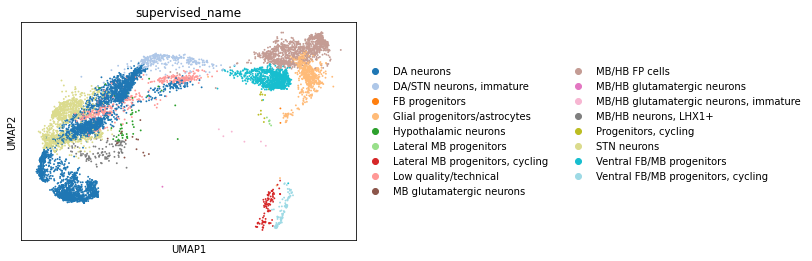

In [34]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('ZH26-HS16_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_ZH26')

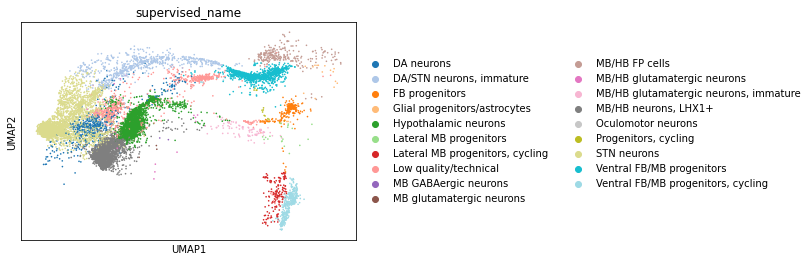

In [35]:
adata_pooltype_individual = adata.obs['individual_pooltype'].str.contains('O11045-4593_Intraspecies')
sc.pl.umap(adata[adata_pooltype_individual,:],color='supervised_name', save='_celltype_O11045')

In [46]:
# Set color scheme
custom_colors = {
    'DA neurons': 'steelblue',
    'DA/STN neurons, immature': 'lightsteelblue',
    'STN neurons': 'khaki',
    'MB glutamatergic neurons': 'saddlebrown',
    'MB/HB glutamatergic neurons': 'violet',
    'MB/HB glutamatergic neurons, immature': 'plum',
    'MB/HB neurons, LHX1+': 'gray',
    'Oculomotor neurons': 'lightgray',
    'MB GABAergic neurons': 'mediumpurple',
    'Hypothalamic neurons': 'forestgreen',
    'Ventral FB/MB progenitors': 'deepskyblue',
    'Ventral FB/MB progenitors, cycling': 'paleturquoise',
    'FB progenitors': 'darkorange',
    'Lateral MB progenitors': 'lightgreen',
    'Lateral MB progenitors, cycling': 'red',
    'Progenitors, cycling': 'yellowgreen',
    'MB/HB FP cells': 'rosybrown',
    'Glial progenitors/astrocytes': 'orange',
    'Low quality/technical': 'lightcoral',
}

In [50]:
adata_D40 = adata[adata.obs['time_point'].isin(['D40'])]

In [52]:
adata_D40_inter_intra = adata_D40[~adata_D40.obs['individual'].isin(['O11045-4593','ZG15-M11-10','ZH26-HS16'])]
adata_D40_inter_intra = adata_D40_inter_intra[~adata_D40_inter_intra.obs['individual_pooltype'].isin(['nan_Interspecies','nan_Intraspecies'])]

View of AnnData object with n_obs × n_vars = 49061 × 51861
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'pool_type', 'species', 'time_point', 'experiment', 'day_10x', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts', 'leiden', 'supervised_name', 'individual_pooltype'
    var: 'gene_ids-D100_M_0-4_Chimp', 'feature_types-D100_M_0-4_Chimp', 'genome-D100_M_0-4_Chimp', 'gene_ids-D100_M_0-4_Human', 'feature_types-D100_M_0-4_Human', 'genome-D100_M_0-4_Human', 'gene_ids-D100_M_0-4_Rhesus', 'feature_types-D100_M_0-4_Rhesus', 'genome-D100_M_0-4_Rhesus', 'gene_ids-D100_M_0-5_Chimp', 'feature_types-D100_M_0-5_Chimp', 'genome-D100_M_0-5_Chimp', 'gene_ids-D100_M_0-5_Human', 'feature_types-D100_M_0-5_Human', 'genome-D100_M_0-5_Human', 'gene_ids-D100_M_0-5_Rhesus', 'feature_types-D100_M_0-5_Rhesus', 'genome-D100_M_0-5_Rhesus', 'gene_ids-D100_M_0-6_Chimp', 'feature_types-D100_M_0-6_Chimp', 'genome-D100_M_0-6_Chimp', 'gen

<Figure size 432x288 with 0 Axes>

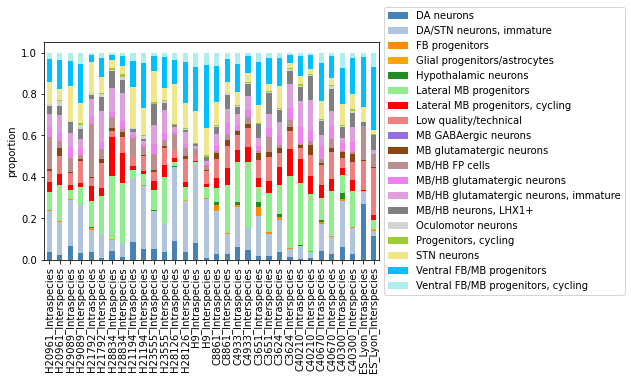

ValueError: Format 'pfd' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff)

<Figure size 432x288 with 0 Axes>

In [61]:
df_plot = adata_D40_inter_intra.obs.groupby(['supervised_name', 'individual_pooltype']).size().reset_index().pivot(columns='supervised_name', index='individual_pooltype', values=0).apply(lambda g: g / g.sum(),1)


#Define the desired order for 'supervised_name'
desired_order = ['H20961_Intraspecies','H20961_Interspecies','H29089_Intraspecies','H29089_Interspecies',
                'H21792_Intraspecies','H21792_Interspecies','H28834_Intraspecies','H28834_Interspecies',
                'H21194_Intraspecies','H21194_Interspecies','H23555_Intraspecies','H23555_Interspecies',
                'H28126_Intraspecies','H28126_Interspecies','H9_Intraspecies','H9_Interspecies',
                'C8861_Intraspecies','C8861_Interspecies','C4933_Intraspecies','C4933_Interspecies',
                'C3651_Intraspecies','C3651_Interspecies','C3624_Intraspecies','C3624_Interspecies',
                'C40210_Intraspecies','C40210_Interspecies','C40670_Intraspecies','C40670_Interspecies',
                'C40300_Intraspecies','C40300_Interspecies','ES_Lyon_Intraspecies','ES_Lyon_Interspecies']
                 
# Set the order as a Categorical type
df_plot.index = pd.Categorical(df_plot.index, categories=desired_order, ordered=True)

# Sort by the new categorical order
df_plot = df_plot.sort_index()


# Plot
f = plt.figure()
ax = df_plot.plot(kind='bar', legend=False, stacked=True, color=colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5)),
plt.ylabel('proportion')
plt.show()
plt.savefig('boxplot_D40-pooltype-individual.pdf', format='pfd')